# Muon vs SGD：τ 调度（联合训练 ↔ 块交替）

两层线性网络 $\hat y = W_2 W_1 x$，目标 $W_2 W_1 \approx A$（$d=64$，`seed=0`）。

全程优化 compose loss
$$L = \|W_2 W_1 - A\|^2 / \|A\|^2$$
直到 $\|W_2 W_1 - A\| / \|A\| \le \text{THRESHOLD}$ 的 **steps**（达到阈值的训练步数）。

**τ 调度**（冻结另一层的步数）：
- $\tau = 0$：每步同时更新 $W_1$ 与 $W_2$ → **联合 GD**（绿色）
- $\tau \ge 1$：交替块——$\tau$ 步只训 $W_1$（蓝），再 $\tau$ 步只训 $W_2$（红）

**对比路径**
- SGD 训 $W_1$ → SGD 训 $W_2$（实线）
- Muon 训 $W_1$ → SGD 训 $W_2$（虚线）

Muon：与 SGD 相同 lr；NS 正交化梯度，更新范数 lr $\|g\|$；`NS_STEPS=5`。


In [1]:
import math

import matplotlib.pyplot as plt
import torch

%matplotlib inline

torch.set_default_dtype(torch.float64)

D = 64
LR = 2e-2
SEED = 0
THRESHOLD = 0.05
MAX_STEPS = 41200
NS_STEPS = 5
TAU_VALUES = [0, 1, 5, 10, 50, 200, 600]

PHASE_STYLE = {
    "joint": {"color": "#16a34a", "label": "joint (W1+W2)"},
    "w1": {"color": "#2563eb", "label": "W1 update"},
    "w2": {"color": "#dc2626", "label": "W2 update"},
}



libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
def zeropower_via_newtonschulz5(G, steps=3, eps=1e-7):
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16()
    X = X / (X.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(dtype=G.dtype)


def muon_direction(g, ns_steps=NS_STEPS, eps=1e-7):
    direction = zeropower_via_newtonschulz5(g, steps=ns_steps)
    return direction * (g.norm() / (direction.norm() + eps))


class Muon(torch.optim.Optimizer):

    def __init__(self, params, lr=1e-3, ns_steps=NS_STEPS):
        super().__init__(params, dict(lr=lr, ns_steps=ns_steps))

    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            ns_steps = group["ns_steps"]
            for p in group["params"]:
                g = p.grad
                if g is None:
                    continue
                p.data.add_(muon_direction(g, ns_steps=ns_steps), alpha=-lr)


In [3]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_target(d, seed=0):
    gen = torch.Generator().manual_seed(seed)
    return torch.randn(d, d, generator=gen) / math.sqrt(d)


def compose_loss(W2, W1, A, norm_A):
    M = W2 @ W1 - A
    return (M ** 2).sum() / (norm_A**2)


def rand_matrix(d, seed):
    state = torch.cuda.get_rng_state()
    torch.cuda.manual_seed(seed)
    W = torch.randn(d, d, device="cuda") / math.sqrt(d)
    torch.cuda.set_rng_state(state)
    return W


def step_joint(W1, W2, A, norm_A, opt1, opt2):
    opt1.zero_grad(set_to_none=True)
    opt2.zero_grad(set_to_none=True)
    compose_loss(W2, W1, A, norm_A).backward()
    opt1.step()
    opt2.step()


def step_w1_compose(W1, W2, A, norm_A, opt1):
    opt1.zero_grad(set_to_none=True)
    compose_loss(W2, W1, A, norm_A).backward()
    opt1.step()


def step_w2_compose(W1, W2, A, norm_A, opt2):
    opt2.zero_grad(set_to_none=True)
    compose_loss(W2, W1, A, norm_A).backward()
    opt2.step()


In [4]:
def train_tau(
    A,
    w1_optimizer_class,
    tau=0,
    max_steps=MAX_STEPS,
    threshold=THRESHOLD,
    lr=LR,
    seed=SEED,
    ns_steps=NS_STEPS,
):
    set_seed(seed)
    W1 = rand_matrix(D, seed)
    W2 = rand_matrix(D, seed + 1)
    norm_A = A.norm().item()

    losses, phases = [], []
    if w1_optimizer_class is Muon:
        opt1 = w1_optimizer_class([W1], lr=lr, ns_steps=ns_steps)
    else:
        opt1 = w1_optimizer_class([W1], lr=lr)
    opt2 = torch.optim.SGD([W2], lr=lr)
    W1.requires_grad_(True)
    W2.requires_grad_(True)

    step = 0

    def record(phase):
        losses.append(compose_loss(W2, W1, A, norm_A).item())
        phases.append(phase)

    w1_opt = "muon" if w1_optimizer_class is Muon else "sgd"

    record("init")
    if losses[-1] <= threshold ** 2:
        return _pack(losses, phases, tau, w1_opt)

    if tau == 0:
        while step < max_steps and losses[-1] > threshold ** 2:
            step_joint(W1, W2, A, norm_A, opt1, opt2)
            step += 1
            record("joint")
        return _pack(losses, phases, tau, w1_opt)

    block = 0
    while step < max_steps and losses[-1] > threshold ** 2:
        if block % 2 == 0:
            for _ in range(tau):
                if step >= max_steps or losses[-1] <= threshold ** 2:
                    break
                step_w1_compose(W1, W2, A, norm_A, opt1)
                step += 1
                record("w1")
        else:
            for _ in range(tau):
                if step >= max_steps or losses[-1] <= threshold ** 2:
                    break
                step_w2_compose(W1, W2, A, norm_A, opt2)
                step += 1
                record("w2")
        block += 1

    return _pack(losses, phases, tau, w1_opt)


def _pack(losses, phases, tau, w1_opt):
    rel = [math.sqrt(v) for v in losses]
    return dict(
        losses=losses,
        rel_dist=rel,
        phases=phases,
        tau=tau,
        w1_opt=w1_opt,
        steps=len(losses) - 1,
    )


def run_label(run):
    return "joint" if run["tau"] == 0 else f"tau={run['tau']}"


def converged(run):
    return run["rel_dist"][-1] <= THRESHOLD


def delta_steps(sgd_run, muon_run):
    if not converged(sgd_run) or not converged(muon_run):
        return None
    return sgd_run["steps"] - muon_run["steps"]


def run_compare_sweep(A, tau_values, ns_steps=NS_STEPS):
    pairs = []
    print("\n" + "=" * 72)
    print("Compare SGD W1 vs Muon W1 (W2 always SGD)")
    print(f"  lr={LR}  ns_steps={ns_steps}")
    print("=" * 72)
    for tau in tau_values:
        sgd_run = train_tau(A, torch.optim.SGD, tau=tau)
        muon_run = train_tau(A, Muon, tau=tau, ns_steps=ns_steps)
        label = run_label(sgd_run)
        pairs.append((label, sgd_run, muon_run))
        d = delta_steps(sgd_run, muon_run)
        print(f"\n  [{label}]")
        print(f"    SGD W1 -> SGD W2:  steps={sgd_run['steps']}")
        print(f"    Muon W1 -> SGD W2: steps={muon_run['steps']}")
        print(f"    delta={d} (positive => Muon faster)")
    return pairs


In [5]:
def plot_phased_loss(ax, run, line_style="-", linewidth=1.4, alpha=0.9):
    xs = list(range(len(run["losses"])))
    ys = run["losses"]
    phases = run["phases"]
    seen = set()
    for k in range(1, len(xs)):
        ph = phases[k]
        if ph not in PHASE_STYLE:
            continue
        style = PHASE_STYLE[ph]
        label = None
        if ph not in seen:
            label = style["label"]
            seen.add(ph)
        ax.plot(
            xs[k - 1:k + 1], ys[k - 1:k + 1],
            line_style, color=style["color"],
            linewidth=linewidth, alpha=alpha, label=label,
        )


def plot_phased_gap(ax, sgd_run, muon_run, xlim=None):
    n = min(len(sgd_run["rel_dist"]), len(muon_run["rel_dist"]))
    if xlim is not None:
        n = min(n, xlim[1] + 1)
    gaps = [sgd_run["rel_dist"][k] - muon_run["rel_dist"][k] for k in range(n)]
    phases = sgd_run["phases"]
    seen = set()
    for k in range(1, n):
        ph = phases[k]
        if ph not in PHASE_STYLE:
            continue
        style = PHASE_STYLE[ph]
        label = None
        if ph not in seen:
            label = style["label"]
            seen.add(ph)
        ax.plot(
            [k - 1, k], [gaps[k - 1], gaps[k]],
            color=style["color"], linewidth=1.5, label=label,
        )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("step")
    ax.set_ylabel(r"$\|W_2 W_1 - A\|_{\rm SGD} - \|W_2 W_1 - A\|_{\rm Muon}$" + "\n( / ||A||,  negative => SGD lower)")
    ax.grid(True, alpha=0.3)


def plot_compare_panel(pairs, yscale="log", ns_steps=NS_STEPS, xlim=None, title_suffix=""):
    n = len(pairs)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4.5 * rows), squeeze=False)
    scale_note = "linear y" if yscale == "linear" else "log y"
    fig.suptitle(
        f"Compose loss ({scale_note}){title_suffix}  |  lr={LR}  ns={ns_steps}\n"
        r"SGD solid, Muon dashed; green=joint, blue=W1, red=W2",
        fontsize=11,
    )
    loss_thresh = THRESHOLD ** 2
    for ax, (label, sgd_run, muon_run) in zip(axes.flat, pairs):
        plot_phased_loss(ax, sgd_run, line_style="-", linewidth=1.5)
        plot_phased_loss(ax, muon_run, line_style="--", linewidth=1.5, alpha=0.85)
        ax.axhline(loss_thresh, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(label)
        ax.set_xlabel("step")
        ax.set_ylabel(r"$L = \|W_2 W_1 - A\|^2 / \|A\|^2$")
        if yscale == "log":
            ax.set_yscale("log")
        if xlim is not None:
            ax.set_xlim(xlim)
        ax.grid(True, which="both", alpha=0.25)
    for ax in axes.flat[len(pairs):]:
        ax.axis("off")
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def plot_gap_panel(pairs, ns_steps=NS_STEPS, xlim=None, title_suffix=""):
    n = len(pairs)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4 * rows), squeeze=False)
    zoom = f"  steps 0–{xlim[1]}" if xlim else ""
    fig.suptitle(
        f"Loss gap SGD − Muon{zoom}{title_suffix}  |  lr={LR}  ns={ns_steps}\n"
        r"$<0$: SGD ahead early   $>0$: Muon ahead late",
        fontsize=11,
    )
    for ax, (label, sgd_run, muon_run) in zip(axes.flat, pairs):
        plot_phased_gap(ax, sgd_run, muon_run, xlim=xlim)
        ax.set_title(label)
        if xlim is not None:
            ax.set_xlim(xlim)
    for ax in axes.flat[len(pairs):]:
        ax.axis("off")
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


In [6]:
set_seed(SEED)
A = make_target(D, seed=SEED).cuda()
pairs = run_compare_sweep(A, TAU_VALUES, ns_steps=NS_STEPS)



Compare SGD W1 vs Muon W1 (W2 always SGD)
  lr=0.02  ns_steps=5



  [joint]
    SGD W1 -> SGD W2:  steps=13054
    Muon W1 -> SGD W2: steps=11535
    delta=1519 (positive => Muon faster)



  [tau=1]
    SGD W1 -> SGD W2:  steps=26109
    Muon W1 -> SGD W2: steps=23064
    delta=3045 (positive => Muon faster)



  [tau=5]
    SGD W1 -> SGD W2:  steps=26115
    Muon W1 -> SGD W2: steps=23068
    delta=3047 (positive => Muon faster)



  [tau=10]
    SGD W1 -> SGD W2:  steps=26122
    Muon W1 -> SGD W2: steps=23077
    delta=3045 (positive => Muon faster)



  [tau=50]
    SGD W1 -> SGD W2:  steps=26165
    Muon W1 -> SGD W2: steps=23064
    delta=3101 (positive => Muon faster)



  [tau=200]
    SGD W1 -> SGD W2:  steps=26221
    Muon W1 -> SGD W2: steps=23352
    delta=2869 (positive => Muon faster)



  [tau=600]
    SGD W1 -> SGD W2:  steps=26553
    Muon W1 -> SGD W2: steps=21975
    delta=4578 (positive => Muon faster)


## 图 1：完整 log loss

纵轴为 compose loss（log 尺度）。实线 SGD W1，虚线 Muon W1；颜色标记当前更新哪一层。


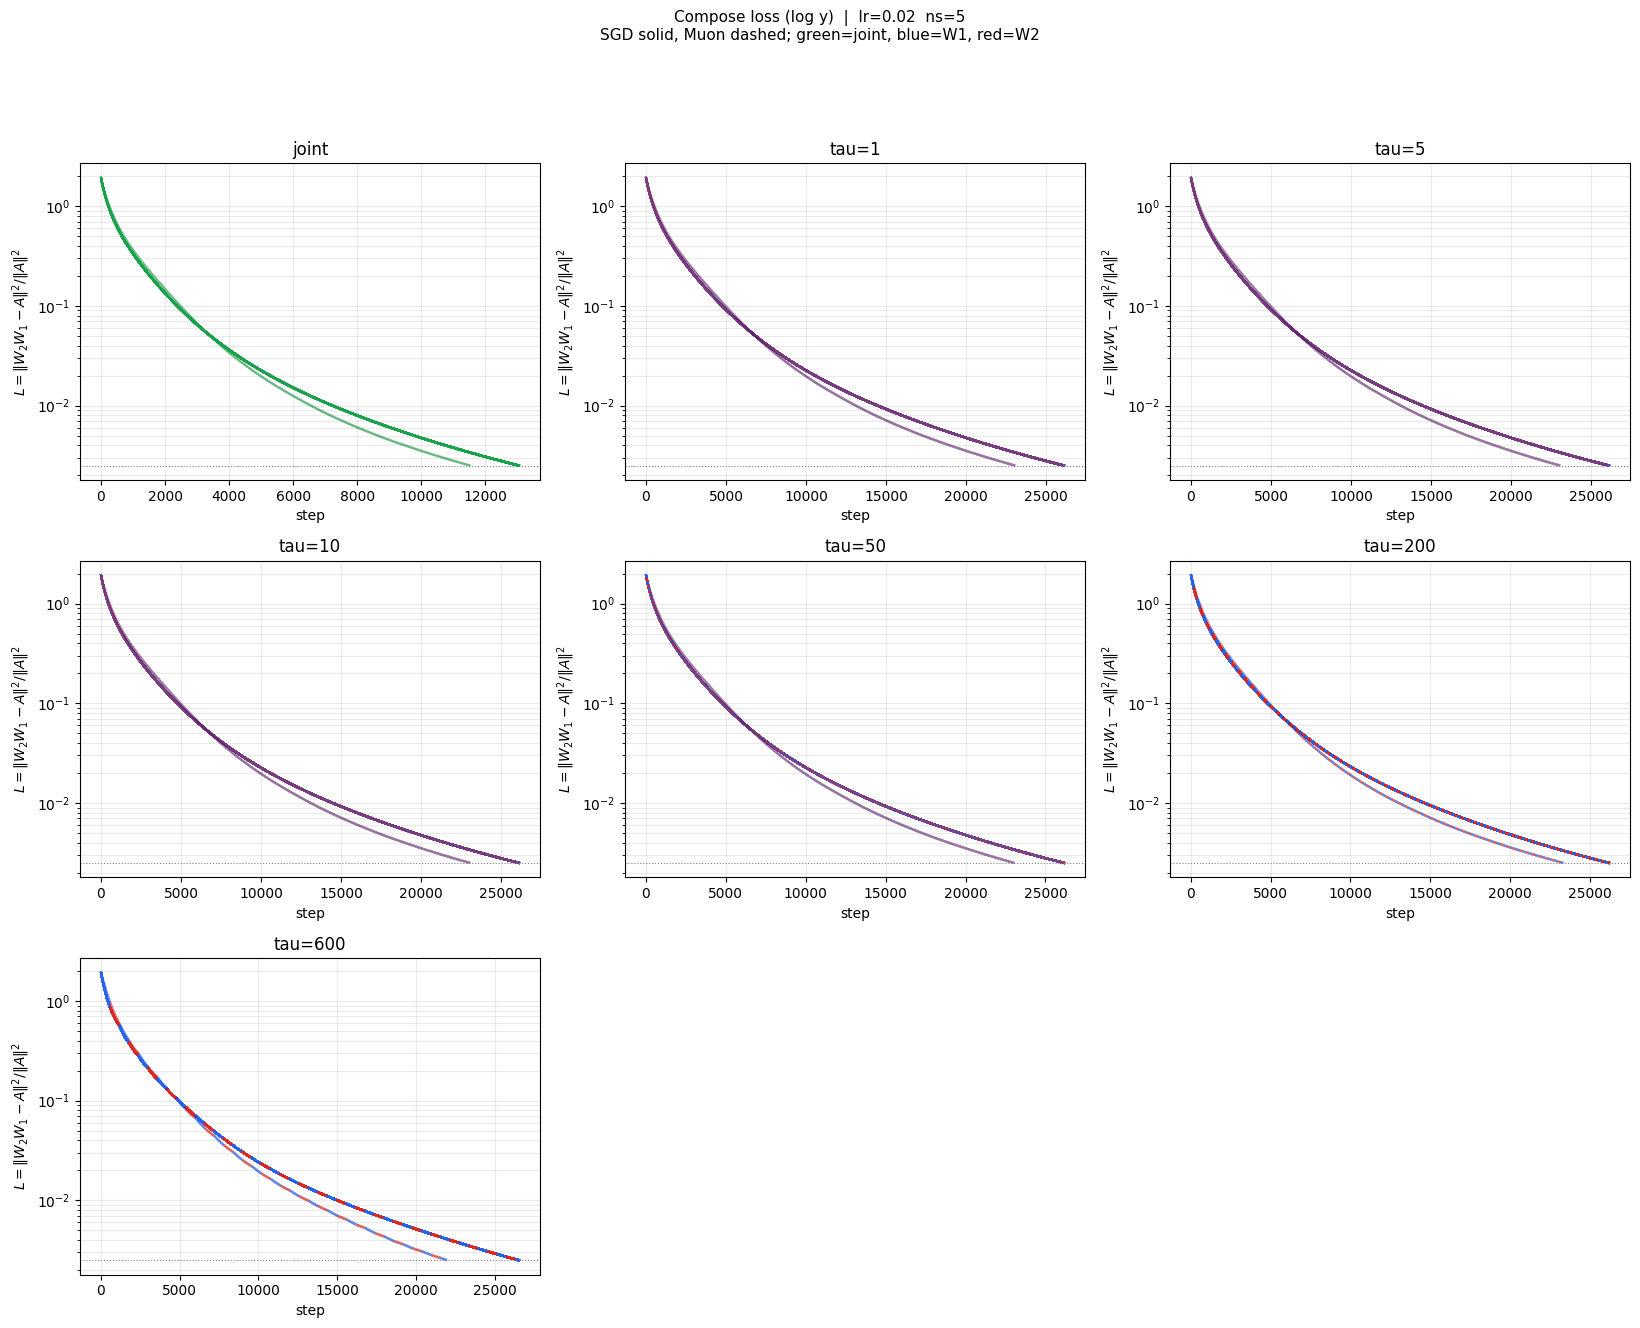

In [7]:
plot_compare_panel(pairs, yscale="log", ns_steps=NS_STEPS)


## 图 2：前 2000 步线性 loss

线性 y 轴 + 放大早期，便于观察 W1 块（蓝）里 SGD 是否略低于 Muon。


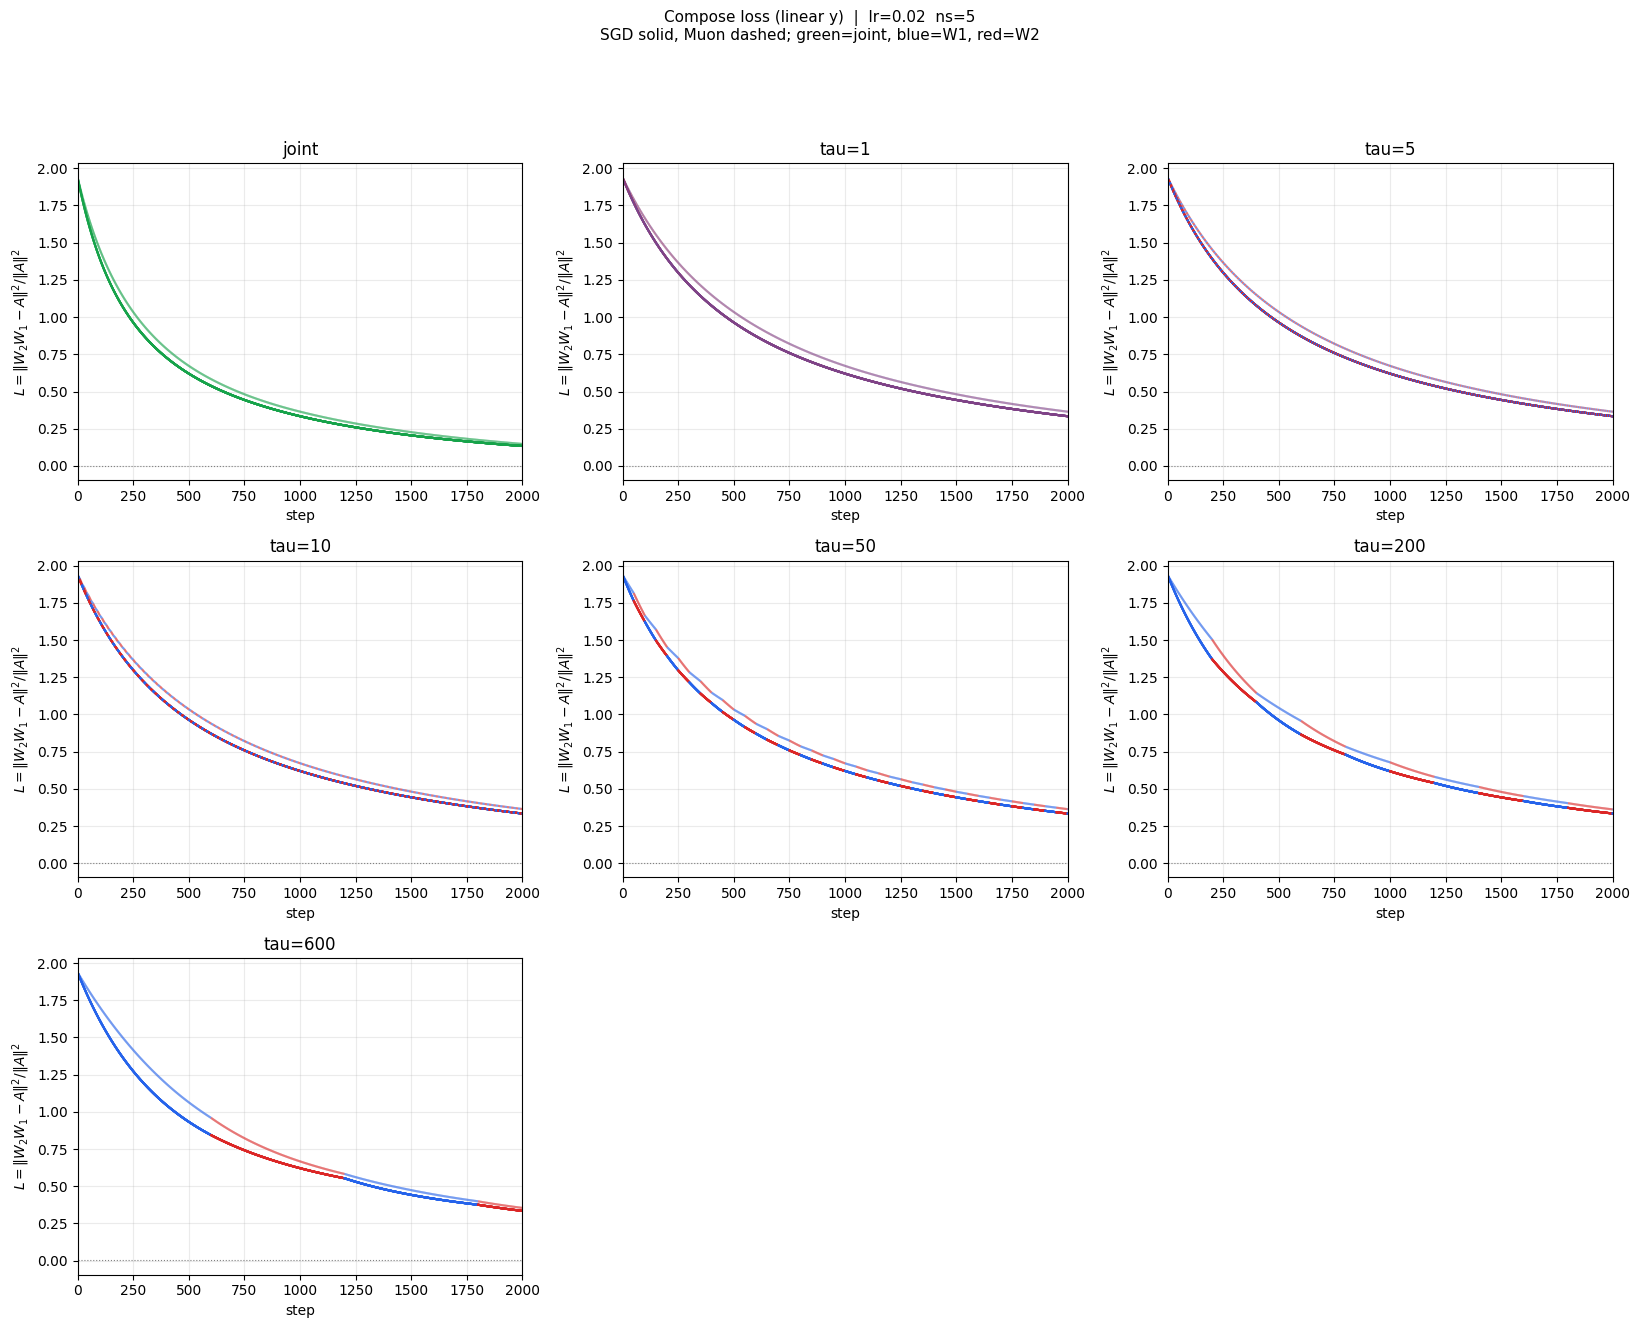

In [8]:
plot_compare_panel(pairs, yscale="linear", ns_steps=NS_STEPS, xlim=(0, 2000))


## 图 3：Gap 曲线（SGD − Muon rel_dist）

- **y < 0**：SGD loss 更低
- **y > 0**：Muon 更低
- **过零**：反超时刻


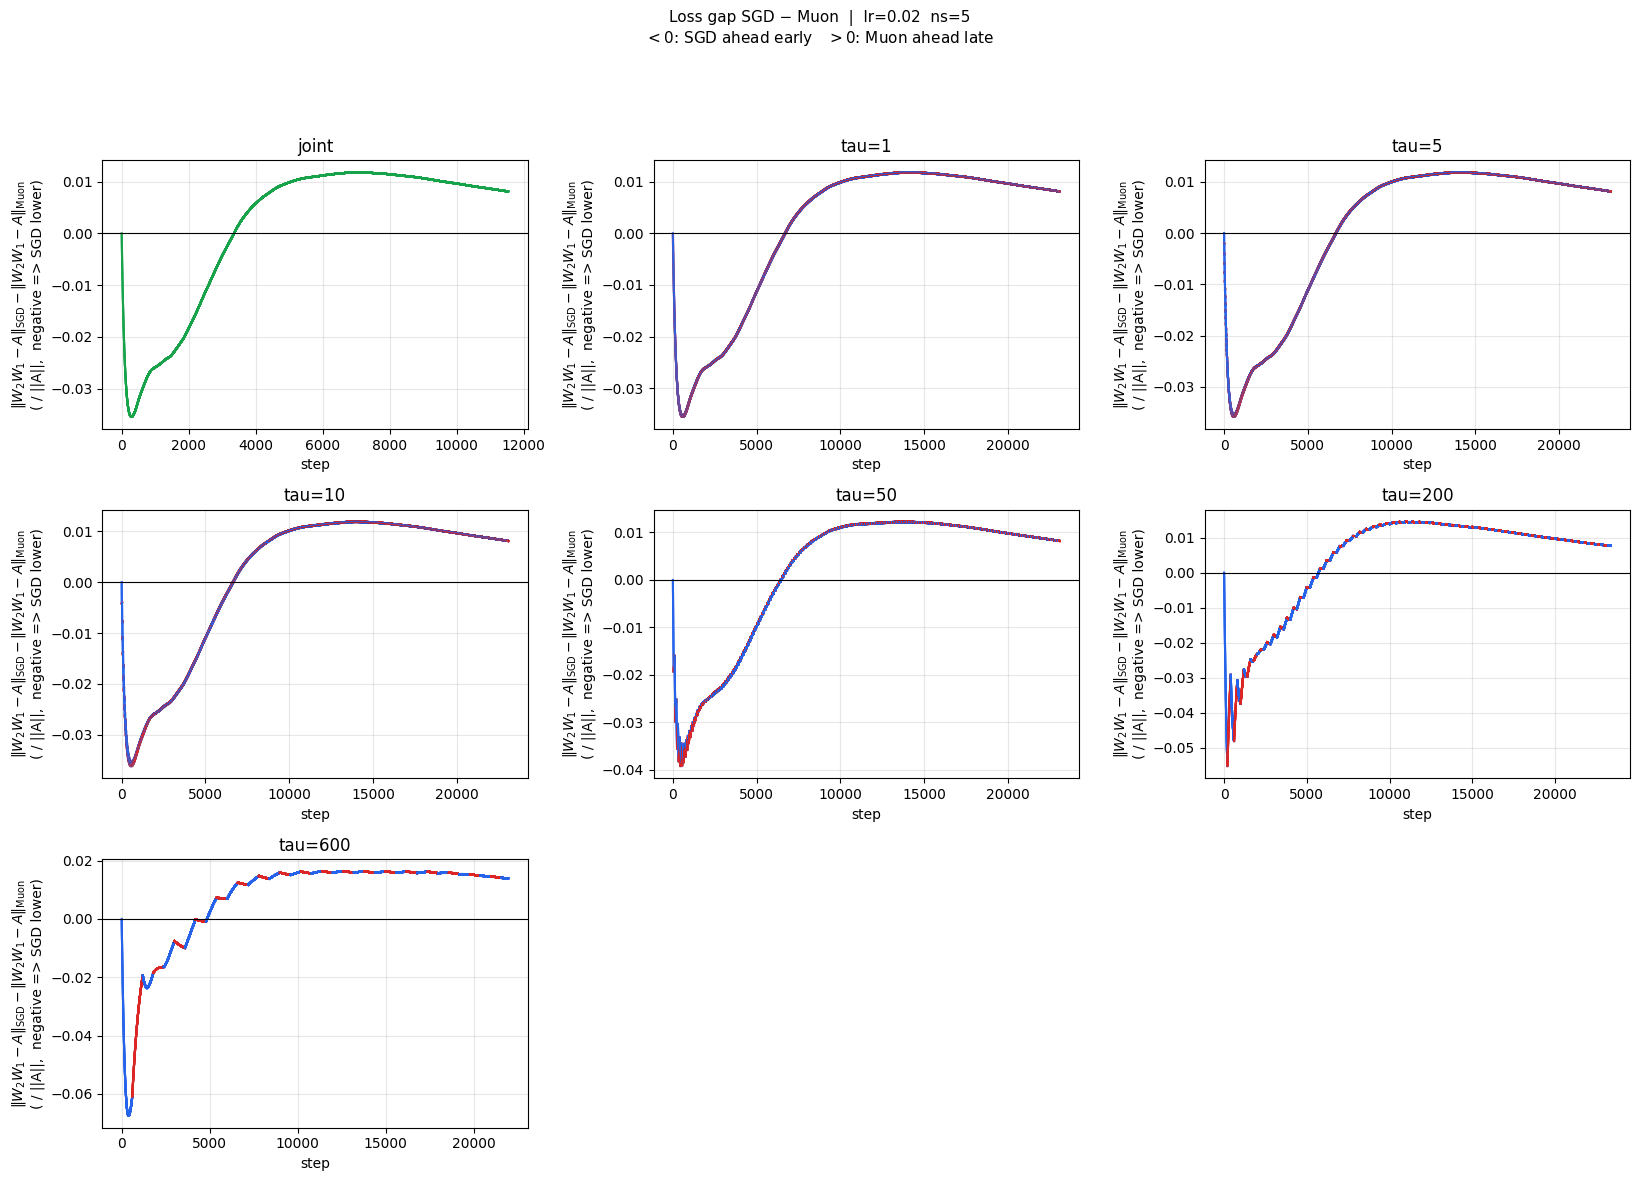

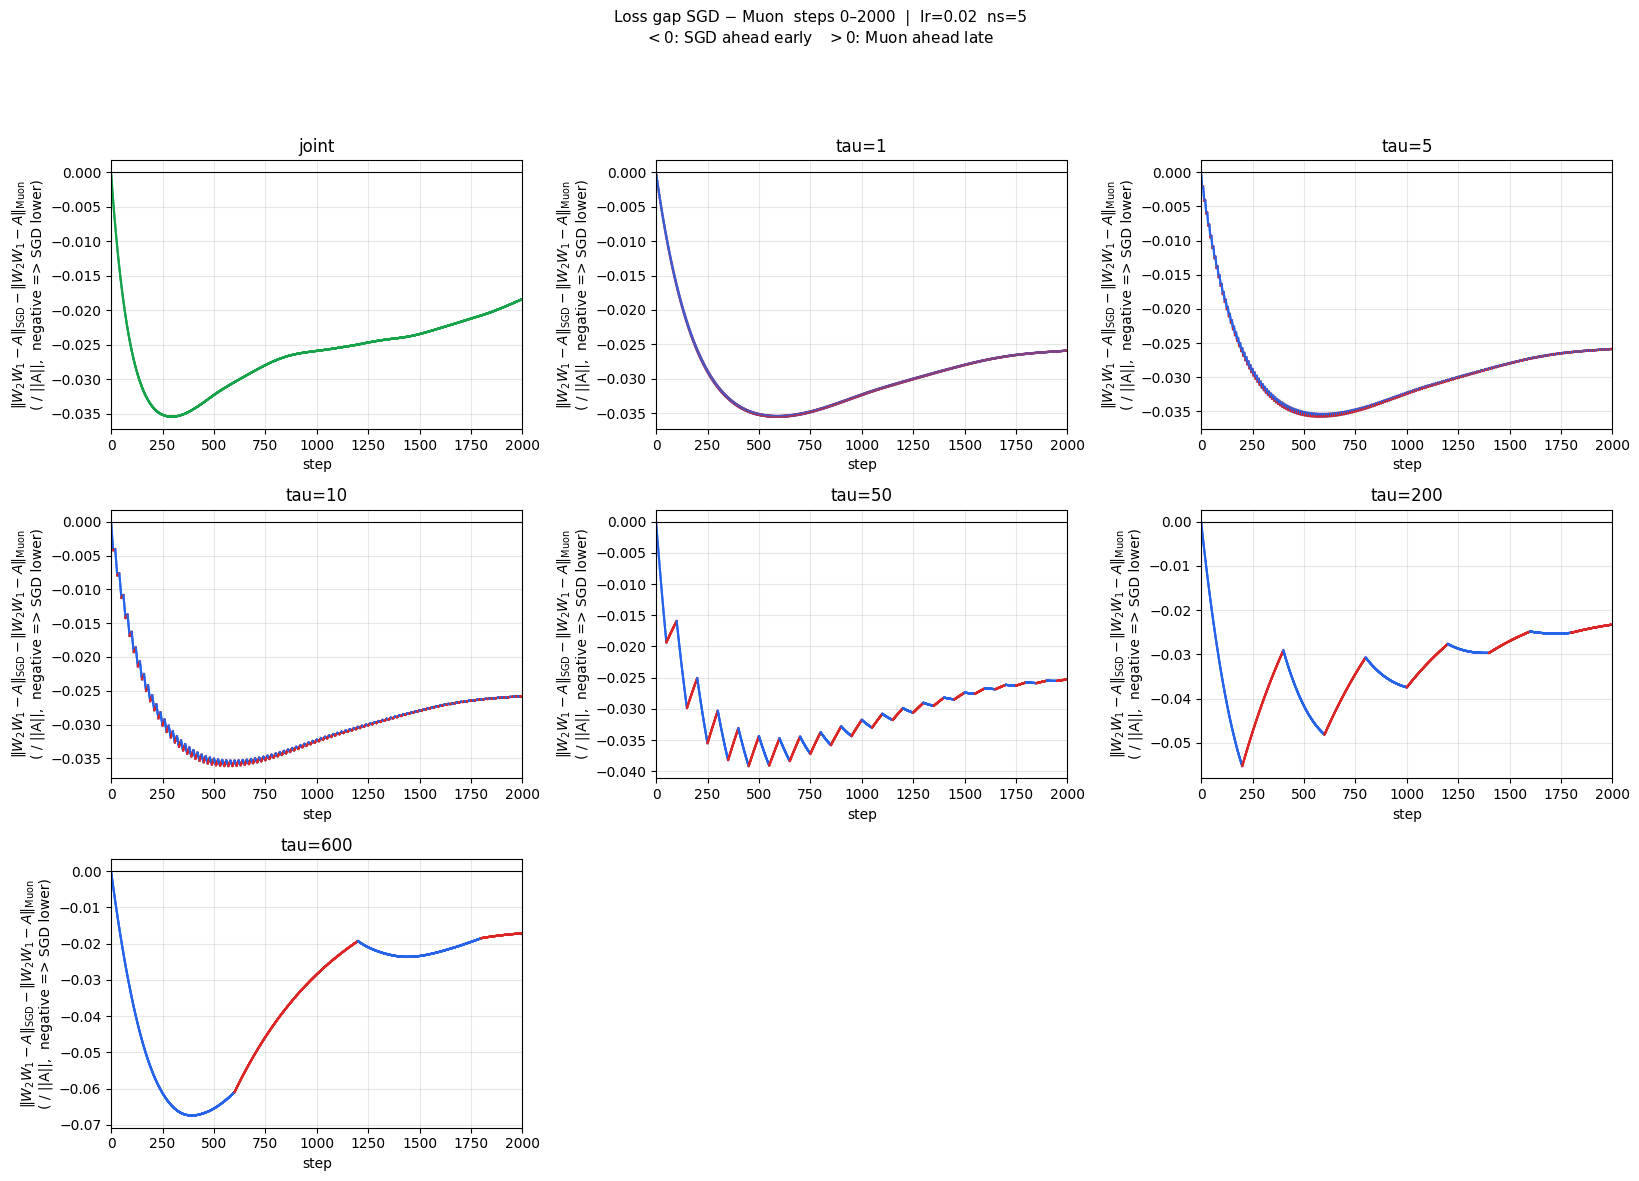

In [9]:
plot_gap_panel(pairs, ns_steps=NS_STEPS)
plot_gap_panel(pairs, ns_steps=NS_STEPS, xlim=(0, 2000))


## 小结

**steps**：达到 THRESHOLD 时的训练步数（未收敛则为 MAX_STEPS）。

**delta = steps_SGD − steps_Muon**（正 ⇒ Muon 更快）。
